In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df = pd.read_csv("../data/cleaned_data.csv")  

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nClass distribution (crop counts):")
print(df["label"].value_counts())

Dataset shape: (2200, 8)

First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Column names: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Class distribution (crop counts):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: 

In [19]:
#x-inputs e.g N,P,K etc, then Y-output/croptype to be predicted
X = df.drop("label", axis=1)
y = df["label"]

In [21]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")



Training samples: 1760, Test samples: 440


In [23]:
#scaling the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
#train the knn model
#looks at the 5 closest data points
# model = KNeighborsClassifier(n_neighbors=5)
# model.fit(X_train, y_train)

# #make predictions
# y_pred = model.predict(X_test)

print("\n--- Testing K values (1 to 20) ---")
k_values  = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)
    print(f"  K={k:2d}  →  Accuracy: {acc:.4f}")


--- Testing K values (1 to 20) ---
  K= 1  →  Accuracy: 0.9795
  K= 2  →  Accuracy: 0.9682
  K= 3  →  Accuracy: 0.9773
  K= 4  →  Accuracy: 0.9727
  K= 5  →  Accuracy: 0.9795
  K= 6  →  Accuracy: 0.9727
  K= 7  →  Accuracy: 0.9705
  K= 8  →  Accuracy: 0.9705
  K= 9  →  Accuracy: 0.9773
  K=10  →  Accuracy: 0.9705
  K=11  →  Accuracy: 0.9727
  K=12  →  Accuracy: 0.9750
  K=13  →  Accuracy: 0.9818
  K=14  →  Accuracy: 0.9659
  K=15  →  Accuracy: 0.9705
  K=16  →  Accuracy: 0.9636
  K=17  →  Accuracy: 0.9659
  K=18  →  Accuracy: 0.9545
  K=19  →  Accuracy: 0.9591
  K=20  →  Accuracy: 0.9432


In [47]:
# #accuracy check
# accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy:", accuracy)


✅ Best K = 13  (Accuracy: 0.9818)


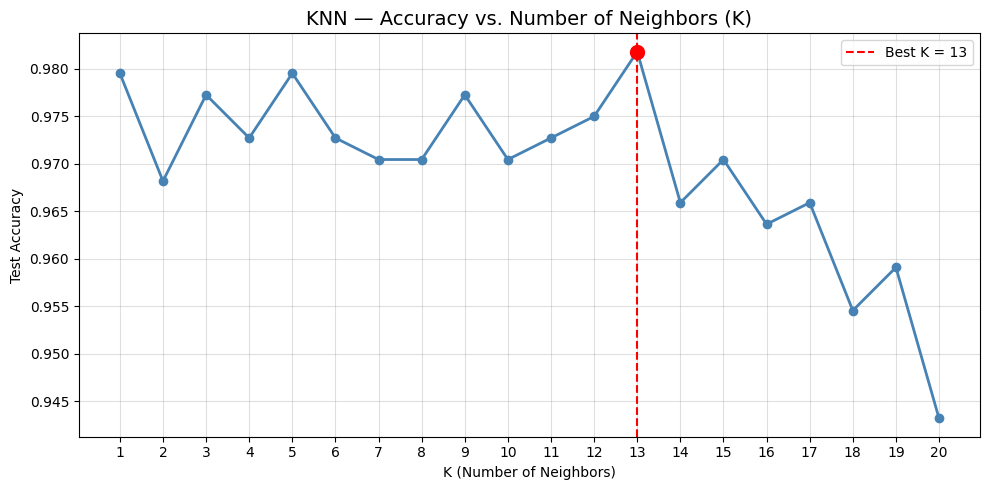

In [49]:
#try diff k values
# for k in range(1, 21):
#     model = KNeighborsClassifier(n_neighbors=k)
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     print(k, accuracy_score(y_test, y_pred))

best_k = k_values[accuracies.index(max(accuracies))]
print(f"\n✅ Best K = {best_k}  (Accuracy: {max(accuracies):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker="o", color="steelblue", linewidth=2)
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.scatter([best_k], [max(accuracies)], color="red", zorder=5, s=100)
plt.title("KNN — Accuracy vs. Number of Neighbors (K)", fontsize=14)
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
#plt.savefig("knn_elbow_curve.png", dpi=150)
plt.show()
#print("Saved: knn_elbow_curve.png")


In [51]:
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))

In [53]:
#cross validation
print("\n--- 5-Fold Cross-Validation with Best K ---")

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
y_all = pd.concat([y_train, y_test]).reset_index(drop=True)

knn_best = KNeighborsClassifier(n_neighbors=best_k)
cv_scores = cross_val_score(knn_best, X_all_scaled, y_all, cv=5, scoring="accuracy")

print(f"  CV Scores per fold: {[round(s, 4) for s in cv_scores]}")
print(f"  Mean CV Accuracy  : {cv_scores.mean():.4f}")
print(f"  Std Deviation     : {cv_scores.std():.4f}")


--- 5-Fold Cross-Validation with Best K ---
  CV Scores per fold: [np.float64(0.9455), np.float64(0.9545), np.float64(0.9614), np.float64(0.9682), np.float64(0.9818)]
  Mean CV Accuracy  : 0.9623
  Std Deviation     : 0.0123


In [55]:
print("\n--- Uniform vs Distance-Weighted KNN ---")

knn_uniform  = KNeighborsClassifier(n_neighbors=best_k, weights="uniform")
knn_distance = KNeighborsClassifier(n_neighbors=best_k, weights="distance")

knn_uniform.fit(X_train_scaled, y_train)
knn_distance.fit(X_train_scaled, y_train)

acc_uniform  = accuracy_score(y_test, knn_uniform.predict(X_test_scaled))
acc_distance = accuracy_score(y_test, knn_distance.predict(X_test_scaled))

print(f"  Uniform  weights → Accuracy: {acc_uniform:.4f}")
print(f"  Distance weights → Accuracy: {acc_distance:.4f}")

# Choose the better model for the rest of the analysis
if acc_distance >= acc_uniform:
    final_model  = knn_distance
    final_weight = "distance"
    final_acc    = acc_distance
else:
    final_model  = knn_uniform
    final_weight = "uniform"
    final_acc    = acc_uniform

print(f"\n✅ Using weights='{final_weight}' for final model  (Accuracy: {final_acc:.4f})")


--- Uniform vs Distance-Weighted KNN ---
  Uniform  weights → Accuracy: 0.9818
  Distance weights → Accuracy: 0.9818

✅ Using weights='distance' for final model  (Accuracy: 0.9818)



=== FINAL KNN MODEL PERFORMANCE ===
  K            : 13
  Weights      : distance
  Test Accuracy: 0.9818 (98.18%)

--- Classification Report ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.90      0.95        20
    mungbean       1.00      1.00      1.0

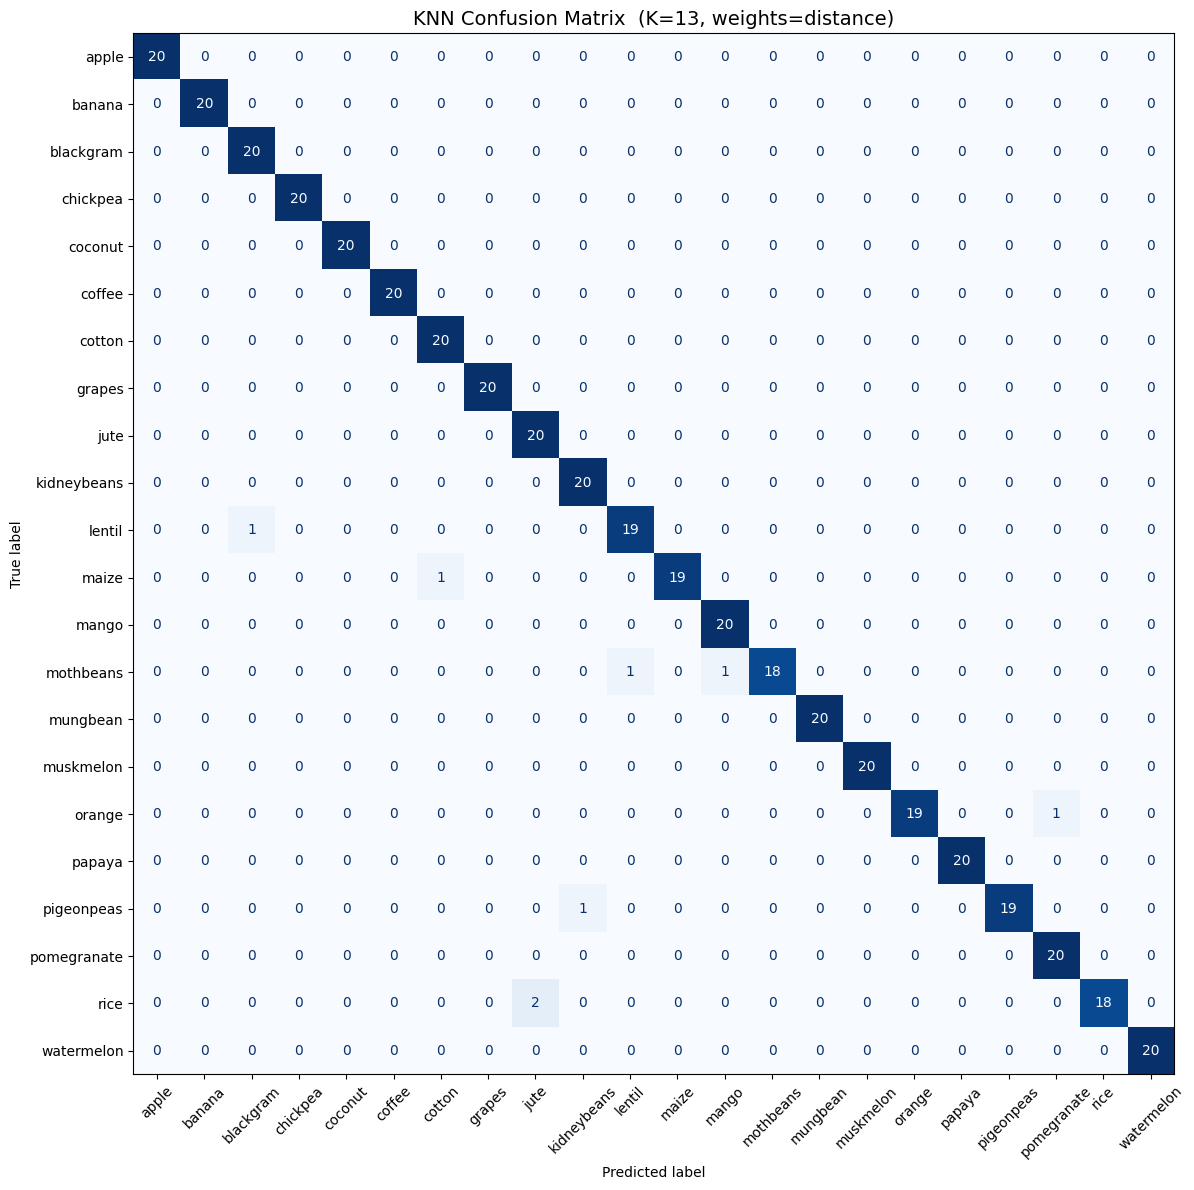

In [57]:
#final model evaluation
y_pred_final = final_model.predict(X_test_scaled)

print("\n=== FINAL KNN MODEL PERFORMANCE ===")
print(f"  K            : {best_k}")
print(f"  Weights      : {final_weight}")
print(f"  Test Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_final))

# ── Confusion Matrix ──────────────────────────
# Shows which crops the model confuses for each other.
# Each row = actual crop, each column = predicted crop.
# Ideal: a bright diagonal, dark everywhere else.
cm     = confusion_matrix(y_test, y_pred_final, labels=final_model.classes_)
fig, ax = plt.subplots(figsize=(14, 12))
disp   = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"KNN Confusion Matrix  (K={best_k}, weights={final_weight})", fontsize=14)
plt.tight_layout()
#plt.savefig("knn_confusion_matrix.png", dpi=150)
plt.show()
#print("Saved: knn_confusion_matrix.png")

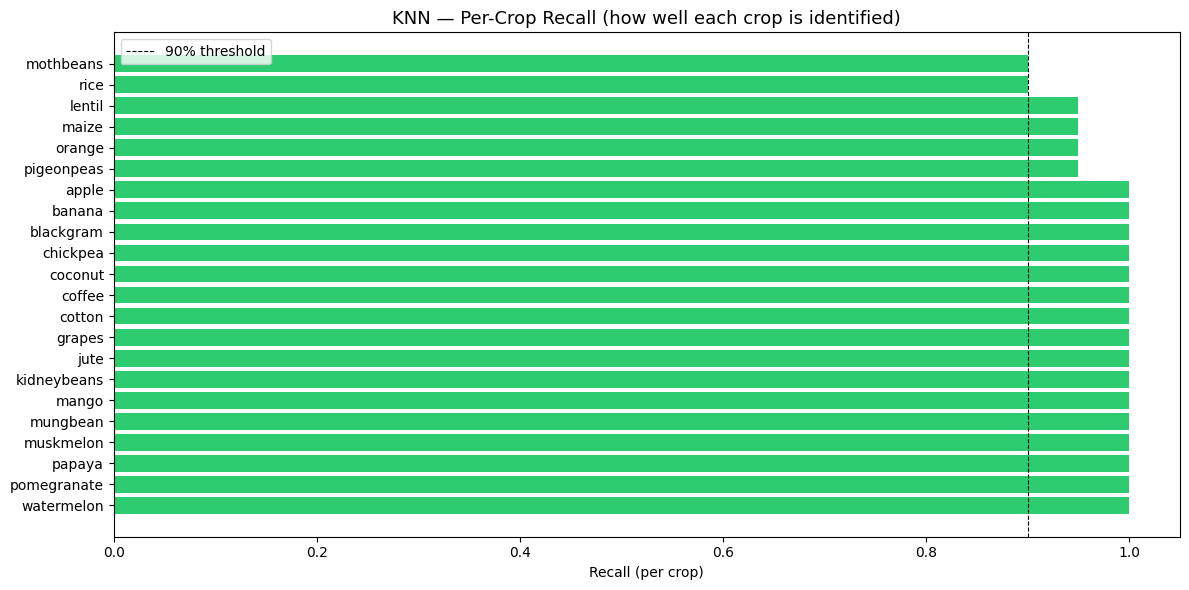

In [63]:
#per class accuracy bar chat
report_dict = classification_report(y_test, y_pred_final, output_dict=True)
classes   = [k for k in report_dict if k not in ("accuracy", "macro avg", "weighted avg")]
recalls   = [report_dict[c]["recall"] for c in classes]

sorted_pairs = sorted(zip(recalls, classes), reverse=True)
sorted_recalls, sorted_classes = zip(*sorted_pairs)

plt.figure(figsize=(12, 6))
colors = ["#2ecc71" if r >= 0.9 else "#e67e22" if r >= 0.75 else "#e74c3c" for r in sorted_recalls]
plt.barh(sorted_classes, sorted_recalls, color=colors)
plt.axvline(x=0.9, color="black", linestyle="--", linewidth=0.8, label="90% threshold")
plt.xlabel("Recall (per crop)")
plt.title("KNN — Per-Crop Recall (how well each crop is identified)", fontsize=13)
plt.xlim(0, 1.05)
plt.legend()
plt.tight_layout()
#plt.savefig("knn_per_class_recall.png", dpi=150)
plt.show()
#print("Saved: knn_per_class_recall.png")

In [65]:
def recommend_crops(N, P, K, temperature, humidity, ph, rainfall, top_n=3):
    """
    Recommend the top N crops for given soil and weather conditions.

    Parameters
    ----------
    N           : Nitrogen content in soil (kg/ha)
    P           : Phosphorus content (kg/ha)
    K           : Potassium content (kg/ha)
    temperature : Average temperature (°C)
    humidity    : Relative humidity (%)
    ph          : Soil pH value
    rainfall    : Annual rainfall (mm)
    top_n       : Number of crop recommendations to return (default 3)

    Returns
    -------
    List of (crop_name, confidence_%) tuples, ranked best → worst
    """
    input_data    = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    input_scaled  = scaler.transform(input_data)

    # predict_proba returns a probability for each possible crop class
    proba         = final_model.predict_proba(input_scaled)[0]
    crop_classes  = final_model.classes_

    # Sort by probability descending, pick top N
    top_indices   = np.argsort(proba)[::-1][:top_n]
    recommendations = [(crop_classes[i], round(proba[i] * 100, 2)) for i in top_indices]
    return recommendations


# ── Demo: test the recommendation function ────
print("\n--- Crop Recommendation Demo ---")
sample_conditions = {
    "N": 90, "P": 42, "K": 43,
    "temperature": 20.8, "humidity": 82.0,
    "ph": 6.5, "rainfall": 202.9
}
print(f"Input conditions: {sample_conditions}")
top_crops = recommend_crops(**sample_conditions)
print("\nTop 3 Recommended Crops:")
for rank, (crop, conf) in enumerate(top_crops, 1):
    print(f"  {rank}. {crop:<15}  confidence: {conf:.1f}%")



--- Crop Recommendation Demo ---
Input conditions: {'N': 90, 'P': 42, 'K': 43, 'temperature': 20.8, 'humidity': 82.0, 'ph': 6.5, 'rainfall': 202.9}

Top 3 Recommended Crops:
  1. rice             confidence: 67.3%
  2. jute             confidence: 32.7%
  3. watermelon       confidence: 0.0%


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [69]:
#summary table
print("\n" + "="*50)
print("          KNN MODEL — FINAL SUMMARY")
print("="*50)
print(f"  Best K              : {best_k}")
print(f"  Weighting           : {final_weight}")
print(f"  Test Accuracy       : {final_acc*100:.2f}%")
print(f"  Mean CV Accuracy    : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"  Uniform  Accuracy   : {acc_uniform*100:.2f}%")
print(f"  Distance Accuracy   : {acc_distance*100:.2f}%")
print("="*50)
# print("\nOutput files:")
# print("  knn_elbow_curve.png")
# print("  knn_confusion_matrix.png")
# print("  knn_per_class_recall.png")


          KNN MODEL — FINAL SUMMARY
  Best K              : 13
  Weighting           : distance
  Test Accuracy       : 98.18%
  Mean CV Accuracy    : 96.23% ± 1.23%
  Uniform  Accuracy   : 98.18%
  Distance Accuracy   : 98.18%
